In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load astronomical object data from CSV
# Dataset contains photometric measurements for star/galaxy classification
df = pd.read_csv('Skyserver_SQL_02_27_2018.csv')

In [4]:
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset Shape: (10000, 18)

First few rows:
          objid          ra       dec         u         g         r         i  \
0  1.237650e+18  183.531326  0.089693  19.47406  17.04240  15.94699  15.50342   
1  1.237650e+18  183.598370  0.135285  18.66280  17.21449  16.67637  16.48922   
2  1.237650e+18  183.680207  0.126185  19.38298  18.19169  17.47428  17.08732   
3  1.237650e+18  183.870529  0.049911  17.76536  16.60272  16.16116  15.98233   
4  1.237650e+18  183.883288  0.102557  17.55025  16.26342  16.43869  16.55492   

          z  run  rerun  camcol  field     specobjid   class  redshift  plate  \
0  15.22531  752    301       4    267  3.722360e+18    STAR -0.000009   3306   
1  16.39150  752    301       4    267  3.638140e+17    STAR -0.000055    323   
2  16.80125  752    301       4    268  3.232740e+17  GALAXY  0.123111    287   
3  15.90438  752    301       4    269  3.722370e+18    STAR -0.000111   3306   
4  16.61326  752    301       4    269  3.722370e+18    STAR  0.

In [5]:
print("\nClass and other cathegorical distributions:")
print(df['class'].value_counts())
print(df['run'].value_counts())
print(df['rerun'].value_counts())
print(df['camcol'].value_counts())
print(df['field'].value_counts())
print(df['plate'].value_counts())
print(df['fiberid'].value_counts())


Class and other cathegorical distributions:
class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64
run
756     3060
752     2086
1345     915
1350     540
1140     527
745      453
1035     396
1412     347
1302     246
1231     245
1331     245
1334     212
1239     197
1336     182
1404     137
1045     112
1402      49
308       31
1411      10
727        4
1356       4
1332       1
1119       1
Name: count, dtype: int64
rerun
301    10000
Name: count, dtype: int64
camcol
4    1834
5    1827
6    1769
2    1712
3    1560
1    1298
Name: count, dtype: int64
field
301    62
302    58
304    56
305    55
309    54
       ..
695     1
660     1
709     1
648     1
406     1
Name: count, Length: 703, dtype: int64
plate
2558    222
2559    221
2895    166
276     156
7456    139
       ... 
4737      1
6321      1
7278      1
3810      1
918       1
Name: count, Length: 487, dtype: int64
fiberid
155    29
138    28
454    27
249    26
11     26
       ..
705     1
9

In [6]:
df['mjd'].min()

51578

In [7]:
df['mjd'].max()

57481

In [8]:
# Check missing values if any
print(df.isnull().sum())

objid        0
ra           0
dec          0
u            0
g            0
r            0
i            0
z            0
run          0
rerun        0
camcol       0
field        0
specobjid    0
class        0
redshift     0
plate        0
mjd          0
fiberid      0
dtype: int64


In [9]:
# Data Preprocessing
# Handle missing values if any
df = df.dropna()

In [10]:
df.shape

(10000, 18)

In [11]:
# Check missing values again if any
print(df.isnull().sum())

objid        0
ra           0
dec          0
u            0
g            0
r            0
i            0
z            0
run          0
rerun        0
camcol       0
field        0
specobjid    0
class        0
redshift     0
plate        0
mjd          0
fiberid      0
dtype: int64


In [12]:
# Encode the target variable (star, galaxy, quasar)
le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])
class_names = le.classes_

print(f"\nClass mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Class mapping: {'GALAXY': 0, 'QSO': 1, 'STAR': 2}


In [13]:
df['class_encoded']

0       2
1       2
2       0
3       2
4       2
       ..
9995    0
9996    0
9997    2
9998    0
9999    0
Name: class_encoded, Length: 10000, dtype: int32

In [14]:
len(df['class_encoded'])

10000

In [15]:
# Feature selection - using astrometry, photometric, and redshift features for classification
features = ['ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'redshift']

X = df[features]
y = df['class_encoded']

In [16]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify = y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Training set size: (7000, 8)
Test set size: (3000, 8)


In [17]:
# Feature scaling (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Hyperparameter tuning using GridSearchCV
print("\nPerforming hyperparameter tuning...")
param_grid = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


Performing hyperparameter tuning...
Best parameters: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Best cross-validation score: 0.9207


In [19]:
# Train final model with best parameters
best_knn = grid_search.best_estimator_

# Cross-validation scores
cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv = 5)
print(f"\nCross-validation score: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Cross-validation score: [0.90785714 0.92071429 0.93285714 0.91428571 0.92785714]
Mean CV accuracy: 0.9207 (+/- 0.0180)


In [21]:
# Make predictions
y_pred = best_knn.predict(X_test_scaled)
y_pred_proba = best_knn.predict_proba(X_test_scaled)

In [22]:
# Evaluate the model
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names = class_names))


Test accuracy: 0.9283

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.95      0.90      0.93      1499
         QSO       0.99      0.93      0.96       255
        STAR       0.89      0.96      0.92      1246

    accuracy                           0.93      3000
   macro avg       0.95      0.93      0.94      3000
weighted avg       0.93      0.93      0.93      3000



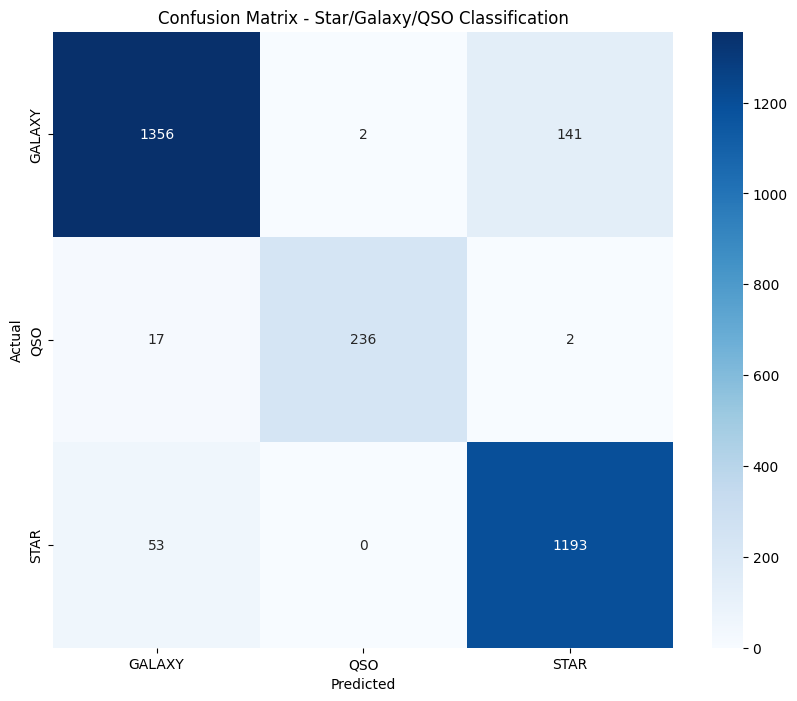

In [23]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = class_names, yticklabels = class_names)
plt.title('Confusion Matrix - Star/Galaxy/QSO Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('knn_confusion_matrix.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [24]:
# Feature importance analysis (using permutation importance)
from sklearn.inspection import permutation_importance

result = permutation_importance(best_knn, X_test_scaled, y_test,
                                n_repeats = 10, random_state = 42)

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending = False)

print("\nFeature importance:")
print(feature_importance)


Feature importance:
    feature  importance       std
7  redshift    0.164667  0.005247
2         u    0.060900  0.003066
6         z    0.053433  0.002486
4         r    0.018233  0.001739
3         g    0.009867  0.002930
0        ra    0.008767  0.001592
1       dec    0.004233  0.002271
5         i    0.003767  0.001758


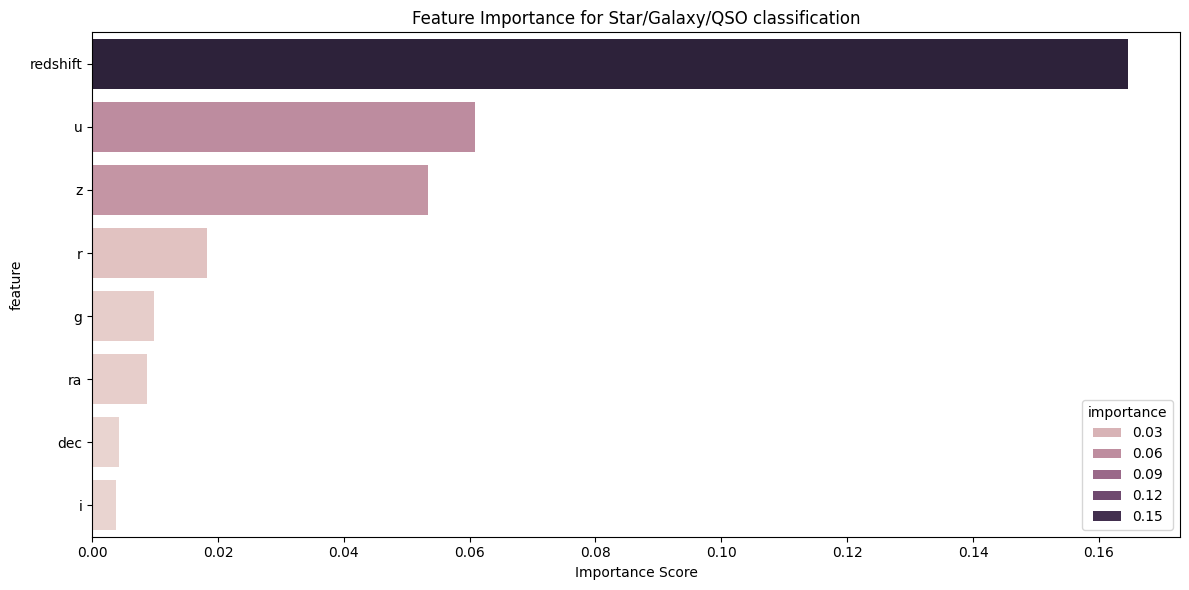

In [25]:
# Plot feature importance
plt.figure(figsize = (12, 6))
sns.barplot(x = 'importance', y = 'feature', data = feature_importance,
           hue = 'importance')
plt.title('Feature Importance for Star/Galaxy/QSO classification')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('knn_feature_importance.png', dpi = 300, bbox_inches = 'tight')
plt.show()